In [39]:
# %%
#clustering
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.decomposition import PCA
import openai
from secret_keys import OPENAI_API_KEY
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("clustering.log"),
        logging.StreamHandler()
    ]
)

logging.info("Script started")

# Load your OpenAI API key
openai.api_key = OPENAI_API_KEY
logging.info("OpenAI API key loaded")

# Reload the embeddings for clustering and visualization
df = pd.read_csv('csv_results_with_embeddings.csv')
def safe_convert(val):
    try:
        if isinstance(val, str):
            embedding = np.array(eval(val))
        else:
            embedding = np.array(val)
        return embedding if embedding.size > 0 else None
    except:
        return None

# Convert embeddings and filter invalid ones
df['Embedding'] = df['Embedding'].apply(safe_convert)
df = df.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(50, len(df)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter_without_progress=500,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    logging.info("t-SNE dimensionality reduction complete")

    # Apply K-Means clustering
    logging.info("Starting K-Means clustering")
    n_clusters = min(6, len(df))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(embeddings_2d)
    logging.info("K-Means clustering complete")

    # Add t-SNE results to DataFrame
    df['TSNE_1'] = embeddings_2d[:, 0]
    df['TSNE_2'] = embeddings_2d[:, 1]
    logging.info("t-SNE results added to DataFrame")

    # Plot using plotly
    logging.info("Creating plotly scatter plot")
    fig = px.scatter(df, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    fig.show()
    fig.write_html('scripts/outputs/t-SNE_visualization.html')
    fig.write_image('scripts/outputs/t-SNE_visualization_plotly.pdf')
    logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    logging.info("Calculating cluster metrics")
    df['Cluster_Size'] = df.groupby('Cluster')['Cluster'].transform('count')
    df['Cluster_Density'] = df.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df))
    logging.info("Cluster metrics calculated")

    # Save results
    df.to_csv('outputs/labeled_clusters.csv', index=False)
    logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    logging.error(f"Error during clustering process: {e}")

logging.info("Script finished")


2026-01-23 14:31:07,844 - INFO - Script started
2026-01-23 14:31:07,845 - INFO - OpenAI API key loaded
2026-01-23 14:31:12,196 - INFO - Starting t-SNE dimensionality reduction
2026-01-23 14:31:15,852 - INFO - t-SNE dimensionality reduction complete
2026-01-23 14:31:15,852 - INFO - Starting K-Means clustering
2026-01-23 14:31:15,858 - INFO - K-Means clustering complete
2026-01-23 14:31:15,858 - INFO - t-SNE results added to DataFrame
2026-01-23 14:31:15,859 - INFO - Creating plotly scatter plot


2026-01-23 14:31:15,888 - ERROR - Error during clustering process: [Errno 2] No such file or directory: 'scripts/outputs/t-SNE_visualization.html'
2026-01-23 14:31:15,889 - INFO - Script finished


In [50]:
# Plot using plotly
logging.info("Creating plotly scatter plot")
fig = px.scatter(df, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
fig.update_traces(marker=dict(size=5))
fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
fig.show()
fig.write_html('outputs/t-SNE_visualization.html')
fig.write_image('outputs/t-SNE_visualization_plotly.pdf')
logging.info("Plotly scatter plot created and saved")

2026-01-23 14:34:37,109 - INFO - Creating plotly scatter plot
2026-01-23 14:34:37,119 - INFO - TemporaryDirectory.cleanup() worked.
2026-01-23 14:34:37,120 - INFO - shutil.rmtree worked.


2026-01-23 14:34:37,172 - INFO - Chromium init'ed with kwargs {}
2026-01-23 14:34:37,173 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-01-23 14:34:37,174 - INFO - Temp directory created: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmp7vmd16ka.
2026-01-23 14:34:37,175 - INFO - Opening browser.
2026-01-23 14:34:37,176 - INFO - Temp directory created: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmpx7d0ynzc.
2026-01-23 14:34:37,177 - INFO - Temporary directory at: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmpx7d0ynzc
2026-01-23 14:34:38,089 - INFO - Conforming 1 to file:///var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmp7vmd16ka/index.html
2026-01-23 14:34:38,090 - INFO - Waiting on all navigates
2026-01-23 14:34:38,698 - INFO - All navigates done, putting them all in queue.
2026-01-23 14:34:38,700 - INFO - Getting tab from queue (has 1)
2026-01-23 14:34:38,700 - INFO - Got 25D3
2026-01-23 14:34:38,700 - INFO - Processin

In [51]:
# %%
# Query the DataFrame for rows containing all words in the title
search_words = "preeclampsia" #replace with your search terms
filtered_df = df[df['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                  Title  Cluster
2     Ambient Temperature and Risk of Preeclampsia: ...        4
3     Temperature and Preeclampsia: Is the Associati...        1
5           Effect of relative humidity on preeclampsia        4
14    Temperature and preeclampsia: Epidemiological ...        4
15    Seasonal variation in the incidence of preecla...        4
...                                                 ...      ...
2820  Treatment of endothelial cells with serum from...        5
2828  Climatic factors and preeclampsia-related hype...        4
2831  Evaluation of plasma insulin-like growth facto...        3
2839  Increased lipolytic activity and high ratio of...        3
2848  Partial characterization of a novel growth fac...        3

[329 rows x 2 columns]
      Cluster
2           4
3           1
5           4
14          4
15          4
...       ...
2820        5
2828        4
2831        3
2839        3
2848        3

[329 rows x 1 columns]


In [52]:
#brief summary of cluster density for search term
cluster_summary = filtered_df.groupby('Cluster').agg(
    Article_Count=('Title', 'count'),
).reset_index()
print(cluster_summary)

   Cluster  Article_Count
0        0             12
1        1             24
2        2             14
3        3            192
4        4             46
5        5             41


In [53]:
# Subset the DataFrame for Cluster of interest
df_subset = df[(df['Cluster'] == 4)]
print(df_subset['Abstract'])

0       A retrospective study of the meteorological re...
1       Objective: To examine seasonality of pregnancy...
2       Background: Preeclampsia is associated with co...
4       Epidemiological studies have suggested an asso...
5       Purpose of investigation: The authors aimed to...
                              ...                        
2850    Chinese health care was examined by three Amer...
2852    Zinc deficiency and cadmium toxicity have both...
2856    The authors performed a population-based case-...
2886    The syndrome of peri-partum cardiac failure (P...
2919    A retrospective study of the meteorological re...
Name: Abstract, Length: 402, dtype: object


In [54]:
df_subset.shape

(402, 91)

In [55]:
# Convert embeddings and filter invalid ones
df_subset['Embedding'] = df_subset['Embedding'].apply(safe_convert)
df_subset = df_subset.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(50, len(df_subset)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter_without_progress=500,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset['TSNE_1'] = embeddings_2d[:, 0]
    df_subset['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/ipykernel_79258/695857835.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



2026-01-23 14:35:34,302 - INFO - TemporaryDirectory.cleanup() worked.
2026-01-23 14:35:34,302 - INFO - shutil.rmtree worked.


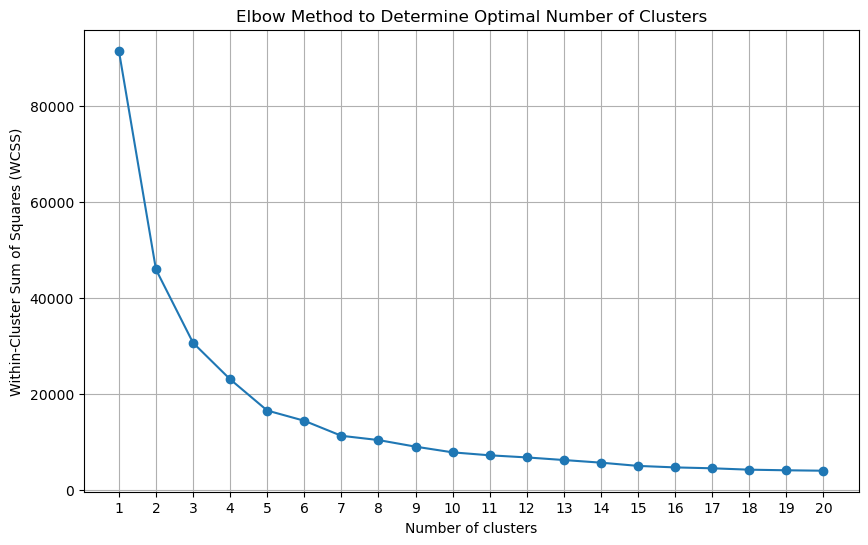

In [56]:
# %%
import matplotlib.pyplot as plt
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [57]:
#Set optimal number of clusters
n_clusters = 5

In [58]:
import os
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    os.makedirs('outputs', exist_ok=True)
    fig.write_html('outputs/t-SNE_visualization_subset.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset['Cluster_Size'] = df_subset.groupby('Cluster')['Cluster'].transform('count')
    df_subset['Cluster_Density'] = df_subset.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset))
    #logging.info("Cluster metrics calculated")
    # Save results
    df_subset.to_csv('outputs/labeled_clusters_subset.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [24]:
# %% Maternal Health
# Query the DataFrame for rows containing all words in the title
search_words = "temperature"
filtered_df = df_subset[df_subset['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                  Title  Cluster
2     Ambient Temperature and Risk of Preeclampsia: ...        2
4     The effects of desert dust storms, air polluti...        4
7     Association between Physiological Equivalent T...        1
12    Ambient temperature during pregnancy and risk ...        4
14    Temperature and preeclampsia: Epidemiological ...        2
...                                                 ...      ...
3059  Ambient Temperature and Markers of Fetal Growt...        1
3098  Ambient Temperature and Risk of Preeclampsia: ...        2
3249  Seasonal variation in pre-eclamptic rate and i...        2
3490  Associations between ambient temperature and p...        3
3492  Seasonal variation in pre-eclamptic rate and i...        2

[117 rows x 2 columns]
      Cluster
2           2
4           4
7           1
12          4
14          2
...       ...
3059        1
3098        2
3249        2
3490        3
3492        2

[117 rows x 1 columns]


In [59]:
# Plot using plotly
logging.info("Creating plotly scatter plot")
fig = px.scatter(df_subset, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
fig.update_traces(marker=dict(size=5))
fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
fig.show()
fig.write_html('outputs/t-SNE_visualization_subset.html')
fig.write_image('outputs/t-SNE_visualization_plotly_subset.pdf')
logging.info("Plotly scatter plot created and saved")

2026-01-23 14:36:00,700 - INFO - Creating plotly scatter plot


2026-01-23 14:36:00,745 - INFO - Chromium init'ed with kwargs {}
2026-01-23 14:36:00,748 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-01-23 14:36:00,749 - INFO - Temp directory created: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmpck0ff1r5.
2026-01-23 14:36:00,751 - INFO - Opening browser.
2026-01-23 14:36:00,752 - INFO - Temp directory created: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmp9fexq9c6.
2026-01-23 14:36:00,752 - INFO - Temporary directory at: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmp9fexq9c6
2026-01-23 14:36:01,670 - INFO - Conforming 1 to file:///var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmpck0ff1r5/index.html
2026-01-23 14:36:01,671 - INFO - Waiting on all navigates
2026-01-23 14:36:02,409 - INFO - All navigates done, putting them all in queue.
2026-01-23 14:36:02,410 - INFO - Getting tab from queue (has 1)
2026-01-23 14:36:02,410 - INFO - Got 286D
2026-01-23 14:36:02,411 - INFO - Processin

In [28]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "temperature"
filtered_df = df_subset[df_subset['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                  Title  Cluster
2     Ambient Temperature and Risk of Preeclampsia: ...        2
4     The effects of desert dust storms, air polluti...        4
7     Association between Physiological Equivalent T...        1
12    Ambient temperature during pregnancy and risk ...        4
14    Temperature and preeclampsia: Epidemiological ...        2
...                                                 ...      ...
3059  Ambient Temperature and Markers of Fetal Growt...        1
3098  Ambient Temperature and Risk of Preeclampsia: ...        2
3249  Seasonal variation in pre-eclamptic rate and i...        2
3490  Associations between ambient temperature and p...        3
3492  Seasonal variation in pre-eclamptic rate and i...        2

[117 rows x 2 columns]
      Cluster
2           2
4           4
7           1
12          4
14          2
...       ...
3059        1
3098        2
3249        2
3490        3
3492        2

[117 rows x 1 columns]


In [60]:
df_subset.shape

(402, 93)

In [61]:
# Subset the DataFrame for Cluster of interest and one more
df_subset_2 = df_subset[(df_subset['Cluster'] != 0)]

In [63]:
df_subset_2.shape

(317, 93)

In [64]:
# Convert embeddings and filter invalid ones
df_subset_2['Embedding'] = df_subset_2['Embedding'].apply(safe_convert)
df_subset_2 = df_subset_2.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_2['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(50, len(df_subset_2)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter_without_progress=500,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_2['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_2['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    logging.error(f"Error during clustering process: {e}")

    #logging.info("Script finished")

/var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/ipykernel_79258/1100148274.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



2026-01-23 14:39:47,910 - INFO - TemporaryDirectory.cleanup() worked.
2026-01-23 14:39:47,911 - INFO - shutil.rmtree worked.


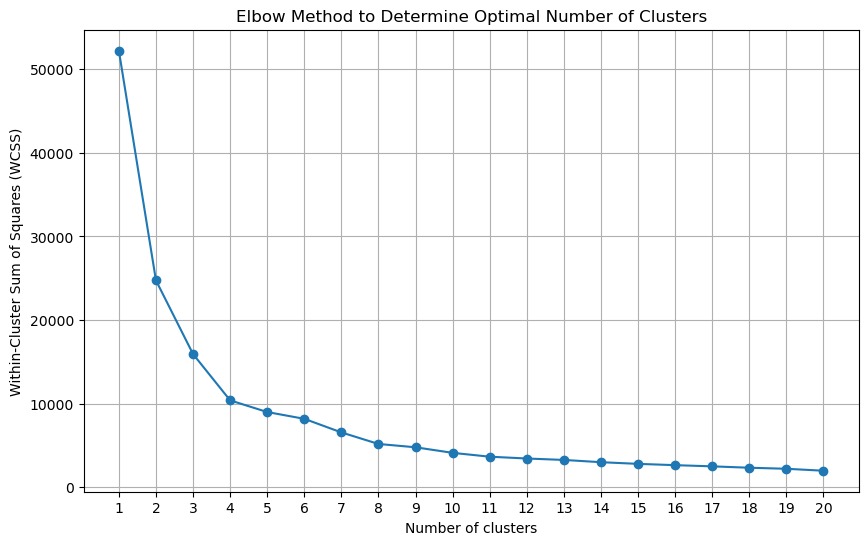

In [65]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [66]:
#Set optimal number of clusters
n_clusters = 4

In [67]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_2['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_2, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_2.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_2.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_2['Cluster_Size'] = df_subset_2.groupby('Cluster')['Cluster'].transform('count')
    df_subset_2['Cluster_Density'] = df_subset_2.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_2))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_2.to_csv('outputs/labeled_clusters_subset_2.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [36]:
# %% Maternal Health
# Query the DataFrame for rows containing all words in the title
search_words = "hypertensive"
filtered_df = df_subset_2[df_subset_2['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                  Title  Cluster
12    Ambient temperature during pregnancy and risk ...        2
16    Potential impact of ambient temperature on mat...        2
19    Association between ambient temperature and hy...        2
25    Maternal exposure to bioclimatic stress and hy...        2
34    Combined effects of ambient temperature and oz...        2
159   Relative humidity, temperature, and hypertensi...        1
171   Maternal exposure to bioclimatic stress and hy...        2
272   Ambient cold exposure amplifies the effect of ...        2
304   Potential impact of ambient temperature on mat...        2
356   A Computational Analysis for Detecting the Hyp...        2
365   Associations between extreme temperature expos...        2
397   Ambient temperature during pregnancy and risk ...        2
532   Ambient temperature exposure during critical w...        2
584   Association between ambient temperature and hy...        2
1252                Hyper

In [64]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "Ambient temperature and mental health: a systematic review and meta-analysis"
filtered_df = df_subset_2[df_subset_2['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
29260  Ambient temperature and mental health: a syste...        2
       Cluster
29260        2


In [68]:
#save plotly figure
fig.write_html('outputs/t-SNE_visualization_subset_2.html')
fig.write_image('outputs/t-SNE_visualization_plotly_subset_2.pdf')

2026-01-23 14:40:17,280 - INFO - Chromium init'ed with kwargs {}
2026-01-23 14:40:17,282 - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-01-23 14:40:17,283 - INFO - Temp directory created: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmpain7dhpq.
2026-01-23 14:40:17,284 - INFO - Opening browser.
2026-01-23 14:40:17,285 - INFO - Temp directory created: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmptjf7s99v.
2026-01-23 14:40:17,285 - INFO - Temporary directory at: /var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmptjf7s99v
2026-01-23 14:40:18,329 - INFO - Conforming 1 to file:///var/folders/l4/8t59gtdn11579mxq800nkfgw0000gn/T/tmpain7dhpq/index.html
2026-01-23 14:40:18,331 - INFO - Waiting on all navigates
2026-01-23 14:40:19,014 - INFO - All navigates done, putting them all in queue.
2026-01-23 14:40:19,015 - INFO - Getting tab from queue (has 1)
2026-01-23 14:40:19,016 - INFO - Got BF65
2026-01-23 14:40:19,017 - INFO - Processin

In [69]:
#save df_subset_2 to csv as 'labeled_clusters_subset_2.csv'
df_subset_2.to_csv('outputs/labeled_clusters_subset_2.csv', index=False)

Need to split at this point to continue maternal review and mental health review

In [65]:
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health = df_subset_2[(df_subset_2['Cluster'] == 2)]

In [66]:
df_subset_mental_health.shape

(7431, 13)

In [76]:
# Convert embeddings and filter invalid ones
df_subset_mental_health['Embedding'] = df_subset_mental_health['Embedding'].apply(safe_convert)
df_subset_mental_health = df_subset_mental_health.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_mental_health['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(20, len(df_subset_mental_health)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_mental_health['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_mental_health['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



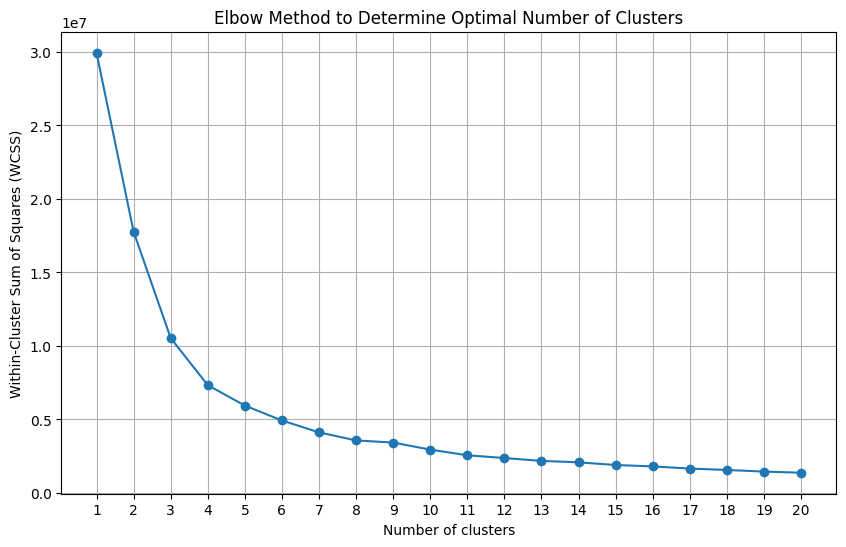

In [77]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [78]:
#Set optimal number of clusters
n_clusters = 4

In [79]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_mental_health['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_mental_health, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_mental_health.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_mental_health.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_mental_health['Cluster_Size'] = df_subset_mental_health.groupby('Cluster')['Cluster'].transform('count')
    df_subset_mental_health['Cluster_Density'] = df_subset_mental_health.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_mental_health))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_mental_health.to_csv('outputs/labeled_clusters_subset_mental_health.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [80]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "Ambient temperature and mental health: a systematic review and meta-analysis"
filtered_df = df_subset_mental_health[df_subset_mental_health['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
print(filtered_df[['Cluster']])

                                                   Title  Cluster
29260  Ambient temperature and mental health: a syste...        2
       Cluster
29260        2


In [81]:
df_subset_mental_health.shape

(7431, 13)

In [82]:
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health_2 = df_subset_mental_health[(df_subset_mental_health['Cluster'] == 2)]

In [83]:
# Convert embeddings and filter invalid ones
df_subset_mental_health_2['Embedding'] = df_subset_mental_health_2['Embedding'].apply(safe_convert)
df_subset_mental_health_2 = df_subset_mental_health_2.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_mental_health_2['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(20, len(df_subset_mental_health_2)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_mental_health_2['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_mental_health_2['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/zr/krd9bths2x19_mx5sdr4lc_r0000gn/T/ipykernel_98532/930077696.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



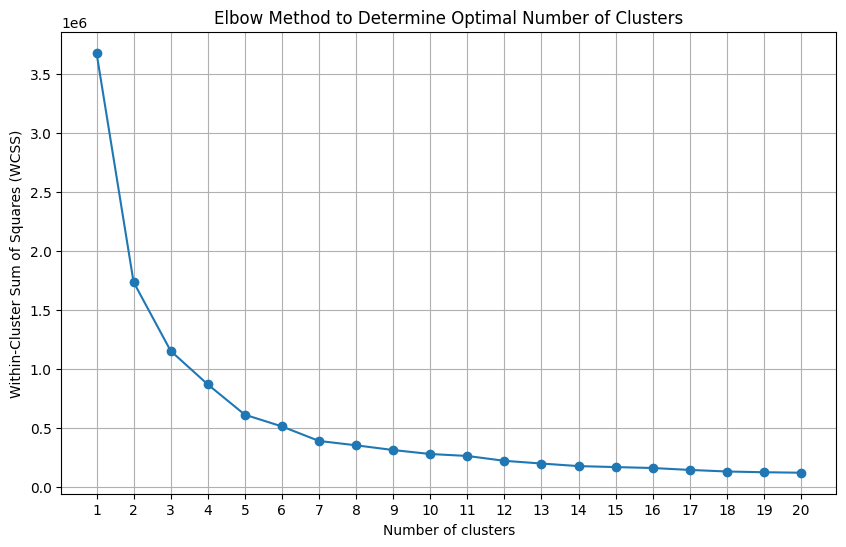

In [84]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [85]:
#Set optimal number of clusters
n_clusters = 5

In [86]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_mental_health_2['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_mental_health_2, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_mental_health_2.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_mental_health.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_mental_health_2['Cluster_Size'] = df_subset_mental_health_2.groupby('Cluster')['Cluster'].transform('count')
    df_subset_mental_health_2['Cluster_Density'] = df_subset_mental_health_2.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_mental_health))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_mental_health_2.to_csv('outputs/labeled_clusters_subset_mental_health_2.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [92]:
# %% Mental Health 
# Query the DataFrame for rows containing all words in the title
search_words = "mental health"
filtered_df = df_subset_mental_health_2[df_subset_mental_health_2['Title'].str.contains(search_words, na= False, case=False)]
#print title and cluster
print(filtered_df[['Title', 'Cluster']])
#count number of studies in each cluster
print(filtered_df['Cluster'].value_counts())

                                                    Title  Cluster
1595    Chronic high temperature exposure, brain struc...        4
2504    A scoping review of the impact of eco-distress...        4
4036                [Planetary health and mental health].        4
5442    A Systematic Review of the Impact of Energy In...        2
15041   The more you know: Insights from integrated pr...        3
29260   Ambient temperature and mental health: a syste...        4
33479   Scoping review of climate change and mental he...        4
39923   Climate distress, climate-sensitive risk facto...        4
41834   High temperatures on mental health: Recognizin...        4
44728   Environmental health, economy, and amenities i...        4
58452   Impact of air pollution and climate change on ...        4
60058   Residential natural hazard risk and mental hea...        4
60499   Examining the non-linear association between a...        4
115725  Climate change and mental health: a causal pat...     

In [93]:
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health_3 = df_subset_mental_health_2[(df_subset_mental_health_2['Cluster'] == 4)]

In [94]:
df_subset_mental_health_3.shape

(399, 13)

In [95]:
# Convert embeddings and filter invalid ones
df_subset_mental_health_3['Embedding'] = df_subset_mental_health_3['Embedding'].apply(safe_convert)
df_subset_mental_health_3 = df_subset_mental_health_3.dropna(subset=['Embedding'])

# Ensure all embeddings have same length by padding/truncating
#max_len = max(x.shape[0] for x in df['Embedding'])
#embeddings_array = np.array([np.pad(x, (0, max_len - x.shape[0])) for x in df['Embedding']])
#load the embedding sarray, all of the smae dimension already
embeddings_array = np.array(df_subset_mental_health_3['Embedding'].values.tolist())
# Scale the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_array)

# Apply PCA to reduce to 50 components (optional)
#pca = PCA(n_components=50, random_state=42)
#pca_result = pca.fit_transform(embeddings_scaled)

# Reduce dimensionality using t-SNE
try:
    #logging.info("Starting t-SNE dimensionality reduction")
    tsne = TSNE(
        n_components=2,          # 2D embedding
        perplexity=min(20, len(df_subset_mental_health_3)-1),           # Start with default
        learning_rate=400,       # Start with default of 200
        n_iter=1000,             # Number of iterations
        metric='cosine',      # Distance metric
        init='pca',              # PCA initialization
        random_state=42,          # For reproducibility
        early_exaggeration=4,
    )
    embeddings_2d = tsne.fit_transform(embeddings_scaled)
    #logging.info("t-SNE dimensionality reduction complete")
    # Add t-SNE results to DataFrame
    df_subset_mental_health_3['TSNE_1'] = embeddings_2d[:, 0]
    df_subset_mental_health_3['TSNE_2'] = embeddings_2d[:, 1]
    #logging.info("t-SNE results added to DataFrame")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

#logging.info("Script finished")

/var/folders/zr/krd9bths2x19_mx5sdr4lc_r0000gn/T/ipykernel_98532/208165447.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/nicbrink/anaconda3/envs/ml_review/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



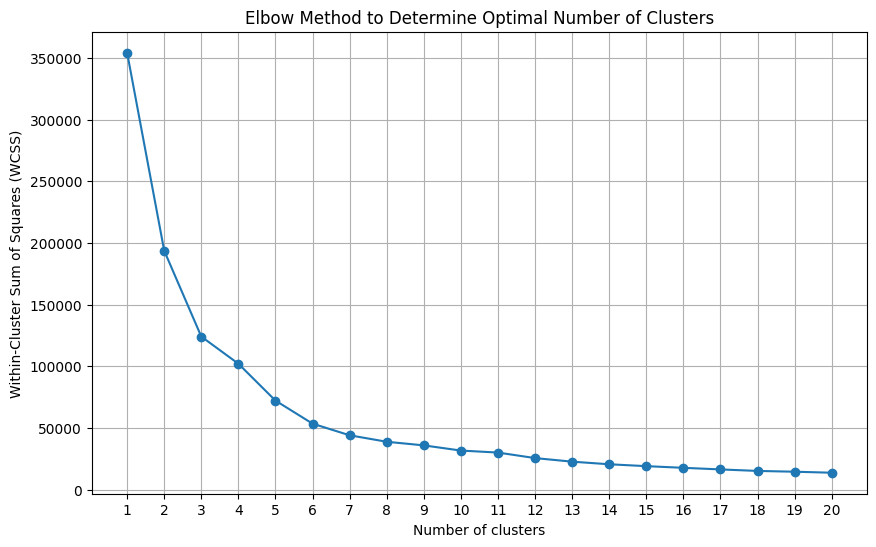

In [96]:
# %%
# Determine Optimal Number of Clusters using Elbow Method
wcss = []
cluster_range = range(1, 21)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings_2d)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(cluster_range, wcss, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [97]:
#Set optimal number of clusters
n_clusters = 3

In [98]:
# Apply K-Means clustering
try:
    #logging.info("Starting K-Means clustering")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df_subset_mental_health_3['Cluster'] = kmeans.fit_predict(embeddings_2d)
    #logging.info("K-Means clustering complete")
    # Plot using plotly
    #logging.info("Creating plotly scatter plot")
    fig = px.scatter(df_subset_mental_health_3, x='TSNE_1', y='TSNE_2', color='Cluster', hover_name='Title')
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(title='t-SNE visualization of PubMed articles with K-Means clustering')
    #fig.show()
    fig.write_html('outputs/t-SNE_visualization_subset_mental_health_3.html')
    #fig.write_image('outputs/t-SNE_visualization_plotly_subset_mental_health.pdf')
    #logging.info("Plotly scatter plot created and saved")

    # Calculate cluster metrics
    #logging.info("Calculating cluster metrics")
    df_subset_mental_health_3['Cluster_Size'] = df_subset_mental_health_3.groupby('Cluster')['Cluster'].transform('count')
    df_subset_mental_health_3['Cluster_Density'] = df_subset_mental_health_3.groupby('Cluster')['Cluster'].transform(lambda x: len(x)/len(df_subset_mental_health_3))
    #logging.info("Cluster metrics calculated")

    # Save results
    df_subset_mental_health_3.to_csv('outputs/labeled_clusters_subset_mental_health_3.csv', index=False)
    #logging.info("Clustering complete - results saved to labeled_clusters.csv")
except Exception as e:
    print(e)
    #logging.error(f"Error during clustering process: {e}")

In [99]:
#subset to cluster 1 for final_df
#mental_health
# Subset the DataFrame for Cluster of interest
df_subset_mental_health_final = df_subset_mental_health_3[(df_subset_mental_health_3['Cluster'] == 1)]

In [100]:
#save to csv
df_subset_mental_health_final.to_csv('outputs/mental_health_final.csv', index=False)

In [101]:
#count number of studies in each cluster
print(df_subset_mental_health_final['Cluster'].value_counts())

Cluster
1    146
Name: count, dtype: int64
